## 1. Install Required Libraries

In [ ]:
!pip -q install "pennylane==0.36.0" "autoray==0.6.11" scikit-learn matplotlib pillow

In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
import numpy as np
import pennylane as qml
import torch
import torchvision
import sklearn
import matplotlib

print("NumPy:", np.__version__)
print("PennyLane:", qml.__version__)
print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("sklearn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)

NumPy: 1.26.4
PennyLane: 0.36.0
Torch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
sklearn: 1.6.1
Matplotlib: 3.10.0


## 2. Mount Google Drive and Verify Project Folders

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from pathlib import Path

project_root = Path("/content/drive/MyDrive/Project Test 2")
raw_dataset_path = project_root / "DFU" / "Patches"

normal_dir = raw_dataset_path / "Normal(Healthy skin)"
abnormal_dir = raw_dataset_path / "Abnormal(Ulcer)"

print("Project root:", project_root)
print("Raw dataset path:", raw_dataset_path)
print("Normal folder exists:", normal_dir.exists())
print("Abnormal folder exists:", abnormal_dir.exists())

normal_files = [f for f in normal_dir.iterdir() if f.is_file()]
abnormal_files = [f for f in abnormal_dir.iterdir() if f.is_file()]

print("Normal images:", len(normal_files))
print("Abnormal images:", len(abnormal_files))

Project root: /content/drive/MyDrive/Project Test 2
Raw dataset path: /content/drive/MyDrive/Project Test 2/DFU/Patches
Normal folder exists: True
Abnormal folder exists: True
Normal images: 543
Abnormal images: 512


## 3. Import Libraries and Set Configuration

In [ ]:
import random
import copy
import json
from typing import Dict, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms, models

import pennylane as qml

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

CONFIG = {
    "project_root": str(project_root),
    "normal_dir": str(normal_dir),
    "abnormal_dir": str(abnormal_dir),
    "save_dir": str(project_root / "outputs"),

    "image_size": 224,
    "batch_size": 16,
    "num_workers": 2,

    "train_size": 0.70,
    "val_size": 0.15,
    "test_size": 0.15,

    "backbone": "resnet50",     # "resnet18" or "resnet50"
    "pretrained": True,
    "freeze_backbone": False,
    "tune_last_block": True,

    "feature_dim": 128,
    "dropout": 0.30,

    "n_qubits": 4,
    "n_q_layers": 1,

    "use_quantum_noise": True,
    "noise_prob": 0.01,
    "amp_damp_prob": 0.01,

    "epochs": 20,    # Here you can select train imgs up to 500
    "lr": 2e-4,
    "weight_decay": 1e-4,
    "grad_clip": 1.0,
    "early_stopping_patience": 15,    # Here also same

    "use_class_weights": True,
    "decision_threshold": 0.5,
}

os.makedirs(CONFIG["save_dir"], exist_ok=True)
print("Save directory:", CONFIG["save_dir"])

Using device: cuda
Save directory: /content/drive/MyDrive/Project Test 2/outputs


## 4. Build Dataset from Folder Structure

In [ ]:
def list_images(folder: Path):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return sorted([str(p) for p in folder.iterdir() if p.is_file() and p.suffix.lower() in exts])

normal_images = list_images(normal_dir)
abnormal_images = list_images(abnormal_dir)

print("Normal images:", len(normal_images))
print("Abnormal images:", len(abnormal_images))

data = []
for path in normal_images:
    data.append((path, 0))   # 0 = Normal

for path in abnormal_images:
    data.append((path, 1))   # 1 = Ulcer

random.shuffle(data)

image_paths = [x[0] for x in data]
labels = [x[1] for x in data]

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=(1 - CONFIG["train_size"]),
    random_state=SEED,
    stratify=labels,
)

relative_test_size = CONFIG["test_size"] / (CONFIG["val_size"] + CONFIG["test_size"])

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=relative_test_size,
    random_state=SEED,
    stratify=temp_labels,
)

print("Train size:", len(train_paths))
print("Val size:", len(val_paths))
print("Test size:", len(test_paths))

Normal images: 543
Abnormal images: 512
Train size: 738
Val size: 158
Test size: 159


## 5. Define Transforms and Dataset Class

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

class DFUPatchDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = int(self.labels[idx])

        if self.transform:
            image = self.transform(image)

        return image, label

train_dataset = DFUPatchDataset(train_paths, train_labels, transform=train_transform)
val_dataset = DFUPatchDataset(val_paths, val_labels, transform=eval_transform)
test_dataset = DFUPatchDataset(test_paths, test_labels, transform=eval_transform)

## 6. Create DataLoaders with Class Balancing

In [ ]:
if CONFIG["use_class_weights"]:
    class_counts = np.bincount(train_labels)
    sample_weights = [1.0 / class_counts[label] for label in train_labels]

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=CONFIG["batch_size"],
        sampler=sampler,
        num_workers=CONFIG["num_workers"],
        pin_memory=True
    )
else:
    train_loader = DataLoader(
        train_dataset,
        batch_size=CONFIG["batch_size"],
        shuffle=True,
        num_workers=CONFIG["num_workers"],
        pin_memory=True
    )

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 47
Val batches: 10
Test batches: 10


## 7. Visualise Sample Training Images

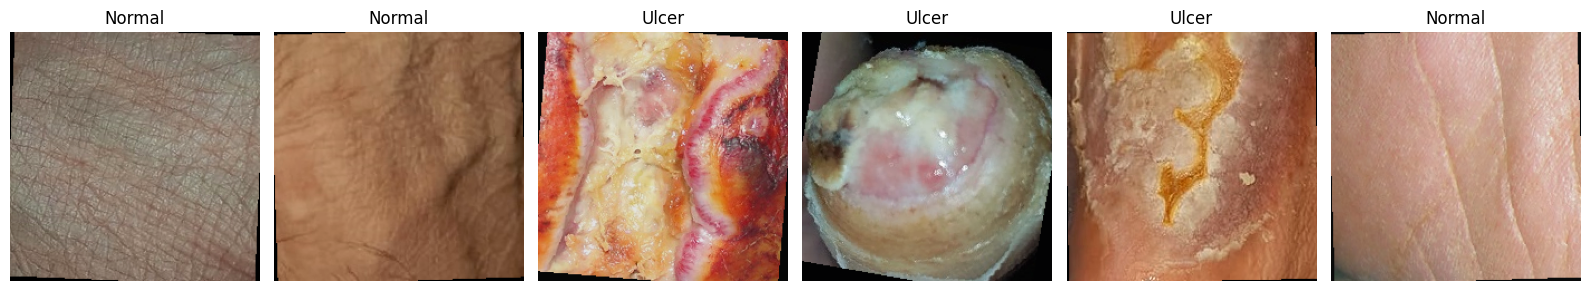

In [ ]:
def show_batch(dataset, n=6):
    fig, axes = plt.subplots(1, n, figsize=(16, 4))
    for i in range(n):
        img, label = dataset[i]
        img = img.permute(1, 2, 0).numpy()
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)

        axes[i].imshow(img)
        axes[i].set_title("Ulcer" if label == 1 else "Normal")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=6)

## 8. Define Binary Classification Metrics

In [ ]:
def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }

    try:
        metrics["roc_auc"] = float(roc_auc_score(y_true, y_prob))
    except Exception:
        metrics["roc_auc"] = 0.0

    cm = confusion_matrix(y_true, y_pred)
    metrics["confusion_matrix"] = cm.tolist()

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        metrics["specificity"] = float(tn / max(tn + fp, 1))
        metrics["sensitivity"] = float(tp / max(tp + fn, 1))
    else:
        metrics["specificity"] = 0.0
        metrics["sensitivity"] = 0.0

    return metrics

## 9. Define Noise-Aware Variational Quantum Layer

In [ ]:
def make_quantum_layer(
    n_qubits=4,
    n_q_layers=1,
    use_noise=False,
    noise_prob=0.01,
    amp_damp_prob=0.01,
):
    backend = "default.mixed" if use_noise else "default.qubit"
    dev = qml.device(backend, wires=n_qubits)

    @qml.qnode(dev, interface="torch", diff_method="best")
    def qnode(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation="Y")

        for layer in range(n_q_layers):
            for i in range(n_qubits):
                qml.Rot(
                    weights[layer, i, 0],
                    weights[layer, i, 1],
                    weights[layer, i, 2],
                    wires=i
                )

                if use_noise:
                    qml.DepolarizingChannel(noise_prob, wires=i)
                    qml.AmplitudeDamping(amp_damp_prob, wires=i)

            for i in range(n_qubits):
                qml.CNOT(wires=[i, (i + 1) % n_qubits])

                if use_noise:
                    qml.DepolarizingChannel(noise_prob, wires=(i + 1) % n_qubits)

        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

    weight_shapes = {"weights": (n_q_layers, n_qubits, 3)}
    return qml.qnn.TorchLayer(qnode, weight_shapes)

## 10. Define Advanced Hybrid Quantum-Classical Model

In [ ]:
class AdvancedHybridDFUModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        if config["backbone"] == "resnet18":
            weights = models.ResNet18_Weights.DEFAULT if config["pretrained"] else None
            backbone = models.resnet18(weights=weights)
            in_features = backbone.fc.in_features
            backbone.fc = nn.Identity()

        elif config["backbone"] == "resnet50":
            weights = models.ResNet50_Weights.DEFAULT if config["pretrained"] else None
            backbone = models.resnet50(weights=weights)
            in_features = backbone.fc.in_features
            backbone.fc = nn.Identity()

        else:
            raise ValueError("Supported backbones: resnet18, resnet50")

        self.backbone = backbone

        if config["freeze_backbone"]:
            for p in self.backbone.parameters():
                p.requires_grad = False

        if config["tune_last_block"] and hasattr(self.backbone, "layer4"):
            for p in self.backbone.layer4.parameters():
                p.requires_grad = True

        self.feature_projector = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(config["dropout"]),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(config["dropout"]),
            nn.Linear(256, config["feature_dim"]),
            nn.ReLU(),
        )

        self.classical_branch = nn.Sequential(
            nn.Linear(config["feature_dim"], 32),
            nn.ReLU(),
            nn.Dropout(config["dropout"] / 1.5),
            nn.Linear(32, 8),
            nn.ReLU(),
        )

        self.quantum_prep = nn.Sequential(
            nn.Linear(config["feature_dim"], 16),
            nn.ReLU(),
            nn.Linear(16, config["n_qubits"]),
        )

        self.q_layer = make_quantum_layer(
            n_qubits=config["n_qubits"],
            n_q_layers=config["n_q_layers"],
            use_noise=config["use_quantum_noise"],
            noise_prob=config["noise_prob"],
            amp_damp_prob=config["amp_damp_prob"],
        )

        self.fusion_head = nn.Sequential(
            nn.Linear(8 + config["n_qubits"], 16),
            nn.ReLU(),
            nn.Dropout(config["dropout"] / 1.5),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.feature_projector(x)

        c = self.classical_branch(x)

        q = self.quantum_prep(x)
        q = torch.tanh(q) * np.pi
        q = self.q_layer(q)

        fused = torch.cat([c, q], dim=1)
        logits = self.fusion_head(fused)
        return logits

## 11. Initialize Model, Loss, Optimizer, and Scheduler

In [ ]:
model = AdvancedHybridDFUModel(CONFIG).to(DEVICE)

train_class_counts = np.bincount(train_labels)
neg_count = train_class_counts[0]
pos_count = train_class_counts[1]

pos_weight = torch.tensor(
    [neg_count / max(pos_count, 1)],
    dtype=torch.float32
).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Positive class weight:", pos_weight.item())
print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 192MB/s]


Positive class weight: 1.0614525079727173
AdvancedHybridDFUModel(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(

## 12. Define Training and Evaluation Functions

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None, train=True):
    model.train(train)

    losses = []
    y_true = []
    y_prob = []

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE).float().unsqueeze(1)

        with torch.set_grad_enabled(train):
            logits = model(images)
            loss = criterion(logits, labels)
            probs = torch.sigmoid(logits)

            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CONFIG["grad_clip"])
                optimizer.step()

        losses.append(loss.item())
        y_true.extend(labels.detach().cpu().numpy().flatten().astype(int).tolist())
        y_prob.extend(probs.detach().cpu().numpy().flatten().tolist())

    avg_loss = float(np.mean(losses))
    metrics = compute_binary_metrics(
        np.array(y_true),
        np.array(y_prob),
        threshold=CONFIG["decision_threshold"]
    )
    return avg_loss, metrics


@torch.no_grad()
def predict(model, loader):
    model.eval()

    y_true = []
    y_prob = []

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE).float().unsqueeze(1)

        logits = model(images)
        probs = torch.sigmoid(logits)

        y_true.extend(labels.cpu().numpy().flatten().astype(int).tolist())
        y_prob.extend(probs.cpu().numpy().flatten().tolist())

    return np.array(y_true), np.array(y_prob)

## 13. Train the Model

In [ ]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": [],
    "train_auc": [],
    "val_auc": [],
}

best_state = None
best_val_loss = float("inf")
best_epoch = -1
patience_counter = 0

for epoch in range(1, CONFIG["epochs"] + 1):
    train_loss, train_metrics = run_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        train=True
    )

    val_loss, val_metrics = run_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        optimizer=None,
        train=False
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_metrics["accuracy"])
    history["val_acc"].append(val_metrics["accuracy"])
    history["train_f1"].append(train_metrics["f1"])
    history["val_f1"].append(val_metrics["f1"])
    history["train_auc"].append(train_metrics["roc_auc"])
    history["val_auc"].append(val_metrics["roc_auc"])

    print(
        f"Epoch {epoch:02d}/{CONFIG['epochs']} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Train F1: {train_metrics['f1']:.4f} | Val F1: {val_metrics['f1']:.4f} | "
        f"Val AUC: {val_metrics['roc_auc']:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        best_state = copy.deepcopy(model.state_dict())

        torch.save(
            {
                "state_dict": best_state,
                "config": CONFIG,
                "best_epoch": best_epoch,
                "best_val_loss": best_val_loss,
            },
            os.path.join(CONFIG["save_dir"], "best_hybrid_dfu_model.pt"),
        )
    else:
        patience_counter += 1

    if patience_counter >= CONFIG["early_stopping_patience"]:
        print("Early stopping triggered.")
        break

print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Epoch 01/20 | Train Loss: 0.6809 | Val Loss: 0.4054 | Train Acc: 0.6220 | Val Acc: 0.9620 | Train F1: 0.4294 | Val F1: 0.9620 | Val AUC: 0.9976
Epoch 02/20 | Train Loss: 0.3922 | Val Loss: 0.0323 | Train Acc: 0.9553 | Val Acc: 1.0000 | Train F1: 0.9587 | Val F1: 1.0000 | Val AUC: 1.0000
Epoch 03/20 | Train Loss: 0.1721 | Val Loss: 0.0359 | Train Acc: 0.9661 | Val Acc: 0.9873 | Train F1: 0.9663 | Val F1: 0.9868 | Val AUC: 0.9994
Epoch 04/20 | Train Loss: 0.3886 | Val Loss: 0.0033 | Train Acc: 0.9756 | Val Acc: 1.0000 | Train F1: 0.9755 | Val F1: 1.0000 | Val AUC: 1.0000
Epoch 05/20 | Train Loss: 0.1050 | Val Loss: 0.0330 | Train Acc: 0.9797 | Val Acc: 0.9937 | Train F1: 0.9783 | Val F1: 0.9935 | Val AUC: 0.9995
Epoch 06/20 | Train Loss: 0.1969 | Val Loss: 0.0007 | Train Acc: 0.9851 | Val Acc: 1.0000 | Train F1: 0.9852 | Val F1: 1.0000 | Val AUC: 1.0000
Epoch 07/20 | Train Loss: 0.0529 | Val Loss: 0.0767 | Train Acc: 0.9892 | Val Acc: 0.9810 | Train F1: 0.9892 | Val F1: 0.9801 | Val AUC:

## 14. Plot Training Curves

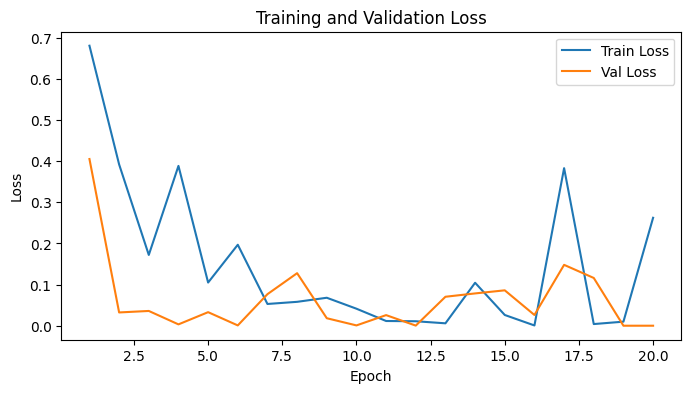

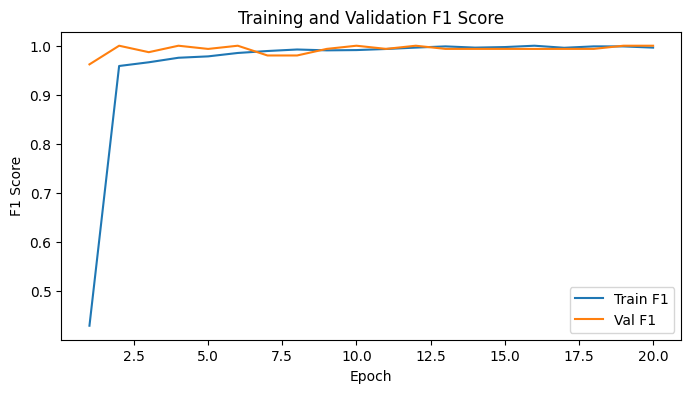

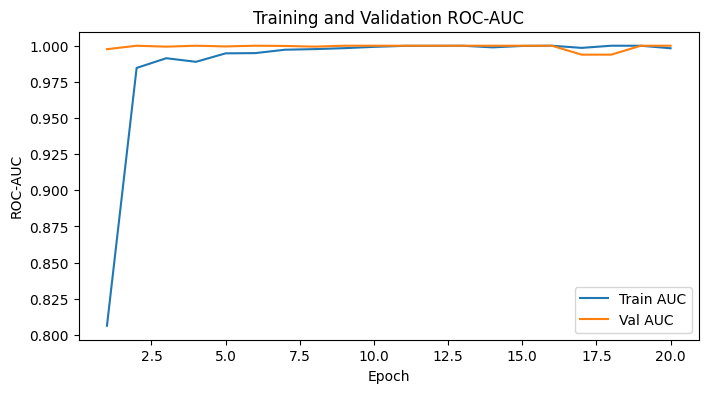

In [ ]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, history["train_f1"], label="Train F1")
plt.plot(epochs_range, history["val_f1"], label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Training and Validation F1 Score")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs_range, history["train_auc"], label="Train AUC")
plt.plot(epochs_range, history["val_auc"], label="Val AUC")
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Training and Validation ROC-AUC")
plt.legend()
plt.show()

## 15. Evaluate the Best Model on the Test Set

In [ ]:
checkpoint = torch.load(
    os.path.join(CONFIG["save_dir"], "best_hybrid_dfu_model.pt"),
    map_location=DEVICE
)
model.load_state_dict(checkpoint["state_dict"])

y_true, y_prob = predict(model, test_loader)

test_metrics = compute_binary_metrics(
    y_true,
    y_prob,
    threshold=CONFIG["decision_threshold"]
)

print(json.dumps(test_metrics, indent=2))

{
  "accuracy": 1.0,
  "precision": 1.0,
  "recall": 1.0,
  "f1": 1.0,
  "roc_auc": 1.0,
  "confusion_matrix": [
    [
      82,
      0
    ],
    [
      0,
      77
    ]
  ],
  "specificity": 1.0,
  "sensitivity": 1.0
}


## 16. Confusion Matrix and Classification Report

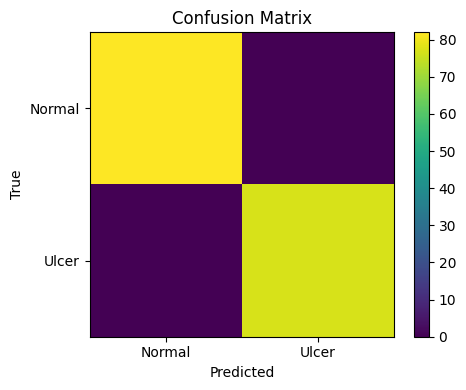

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        82
       Ulcer       1.00      1.00      1.00        77

    accuracy                           1.00       159
   macro avg       1.00      1.00      1.00       159
weighted avg       1.00      1.00      1.00       159



In [ ]:
y_pred = (y_prob >= CONFIG["decision_threshold"]).astype(int)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Normal", "Ulcer"])
plt.yticks([0, 1], ["Normal", "Ulcer"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

print(classification_report(
    y_true,
    y_pred,
    target_names=["Normal", "Ulcer"],
    zero_division=0
))

## 17. Save Final Metrics

In [ ]:
with open(os.path.join(CONFIG["save_dir"], "test_metrics.json"), "w") as f:
    json.dump(test_metrics, f, indent=2)

print("Saved metrics to:", os.path.join(CONFIG["save_dir"], "test_metrics.json"))

Saved metrics to: /content/drive/MyDrive/Project Test 2/outputs/test_metrics.json


## 18. Single Image Prediction

In [ ]:
single_image_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

@torch.no_grad()
def predict_single_image(image_path):
    image = Image.open(image_path).convert("RGB")
    x = single_image_transform(image).unsqueeze(0).to(DEVICE)

    model.eval()
    logits = model(x)
    prob = torch.sigmoid(logits).item()
    pred = 1 if prob >= CONFIG["decision_threshold"] else 0

    print("Image:", image_path)
    print("Predicted class:", "Ulcer" if pred == 1 else "Normal")
    print("Probability of ulcer:", round(prob, 4))

# Example:
# predict_single_image(str(abnormal_files[0]))